In [3]:
import pandas as pd

results_path = 'outputs/ggs/results/SVRModel_c5ba7e02_20260508_1026.csv'

cols_params = ['feature_set', 'window_size', 'n_components', 'clipping_threshold', 
               'kernel', 'C', 'epsilon', 'gamma', 'degree', 'mean_S_score', 
               'mean_C_index', 'mean_MAE', 'mean_RMSE']

df_results = pd.read_csv(results_path)

total = len(df_results)
exitosas = df_results['mean_S_score'].notna().sum()
fallidas = df_results['mean_S_score'].isna().sum()
n_duplicados = df_results.duplicated(subset=cols_params).sum()

print(f"Total configuraciones: {total}")
print(f"Exitosas:              {exitosas}")
print(f"Fallidas (NaN):        {fallidas}")
print(f"Duplicados:            {n_duplicados}")
print(f"Únicas:                {total - n_duplicados}")

Total configuraciones: 13824
Exitosas:              13824
Fallidas (NaN):        0
Duplicados:            0
Únicas:                13824


In [2]:
df_top = (
    df_results
    .dropna(subset=['mean_S_score'])
    .sort_values('mean_S_score', ascending=True)
    .head(10)
    .reset_index(drop=True)
)

df_top[cols_params]

,feature_set,window_size,n_components,clipping_threshold,kernel,C,epsilon,gamma,degree,mean_S_score,mean_C_index,mean_MAE,mean_RMSE
0,A,30,10,115,rbf,10.0,0.10,scale,2,1.824685,0.914618,6.746469,10.242414
1,A,30,10,115,rbf,10.0,0.10,scale,3,1.824685,0.914618,6.746469,10.242414
2,A,30,10,115,rbf,10.0,0.01,scale,3,1.825322,0.914583,6.747740,10.243197
3,A,30,10,115,rbf,10.0,0.01,scale,2,1.825322,0.914583,6.747740,10.243197
4,A,30,10,115,rbf,10.0,0.10,0.01,2,1.828495,0.915369,6.982069,10.351567
5,A,30,10,115,rbf,10.0,0.10,0.01,3,1.828495,0.915369,6.982069,10.351567
6,A,30,10,115,rbf,10.0,0.01,0.01,3,1.830116,0.915366,6.983046,10.353243
7,A,30,10,115,rbf,10.0,0.01,0.01,2,1.830116,0.915366,6.983046,10.353243
8,B,30,10,115,rbf,1.0,0.10,scale,2,1.849759,0.911947,7.240020,10.445129
9,B,30,10,115,rbf,1.0,0.10,scale,3,1.849759,0.911947,7.240020,10.445129


In [4]:
from src.models.svr_model import SVRModel
from src.utils.production_predictor import RULProductionPredictor

best_params_svr = {
    'feature_set':        'A',
    'window_size':        30,
    'n_components':       10,
    'clipping_threshold': 115,
    'kernel':             'rbf',
    'C':                  10.0,
    'epsilon':            0.1,
    'gamma':              'scale',
    'degree':             2,
}

predictor_dt = RULProductionPredictor.from_config(
    model_class=SVRModel,
    params=best_params_svr,
)

print(f"model_name_:        {predictor_dt.model_name_}")
print(f"feature_set:        {predictor_dt.feature_set}")
print(f"window_size:        {predictor_dt.window_size}")
print(f"n_components:       {predictor_dt.n_components}")
print(f"clipping_threshold: {predictor_dt.clipping_threshold}")
print(f"pipeline fitted:    {predictor_dt.pipeline_.is_fitted_}")
print(f"model fitted:       {getattr(predictor_dt.model_, 'is_fitted_', False)}")

Training engines: 140
Test engines: 60
model_name_:        SVRModel
feature_set:        A
window_size:        30
n_components:       10
clipping_threshold: 115
pipeline fitted:    True
model fitted:       True


In [5]:
# Métricas del ganador del DT
dt_metrics = {
    'mean_S_score': 1.824685,
    'mean_C_index': 0.914618,
    'mean_MAE':     6.746469,
    'mean_RMSE':    10.242414,
}

session_dt = predictor_dt.save(metrics=dt_metrics)

print(f"\nstem:     {session_dt.stem}")
print(f"modelo:   {session_dt.path_model}")
print(f"metadata: {session_dt.path_metadata}")

  ✅ Predictor saved: SVRModel_A_30w_10pc_20260510_2152.pkl
  📄 Metadata saved: SVRModel_A_30w_10pc_20260510_2152.json

stem:     SVRModel_A_30w_10pc_20260510_2152
modelo:   outputs/production/models/SVRModel_A_30w_10pc_20260510_2152.pkl
metadata: outputs/production/metadata/SVRModel_A_30w_10pc_20260510_2152.json


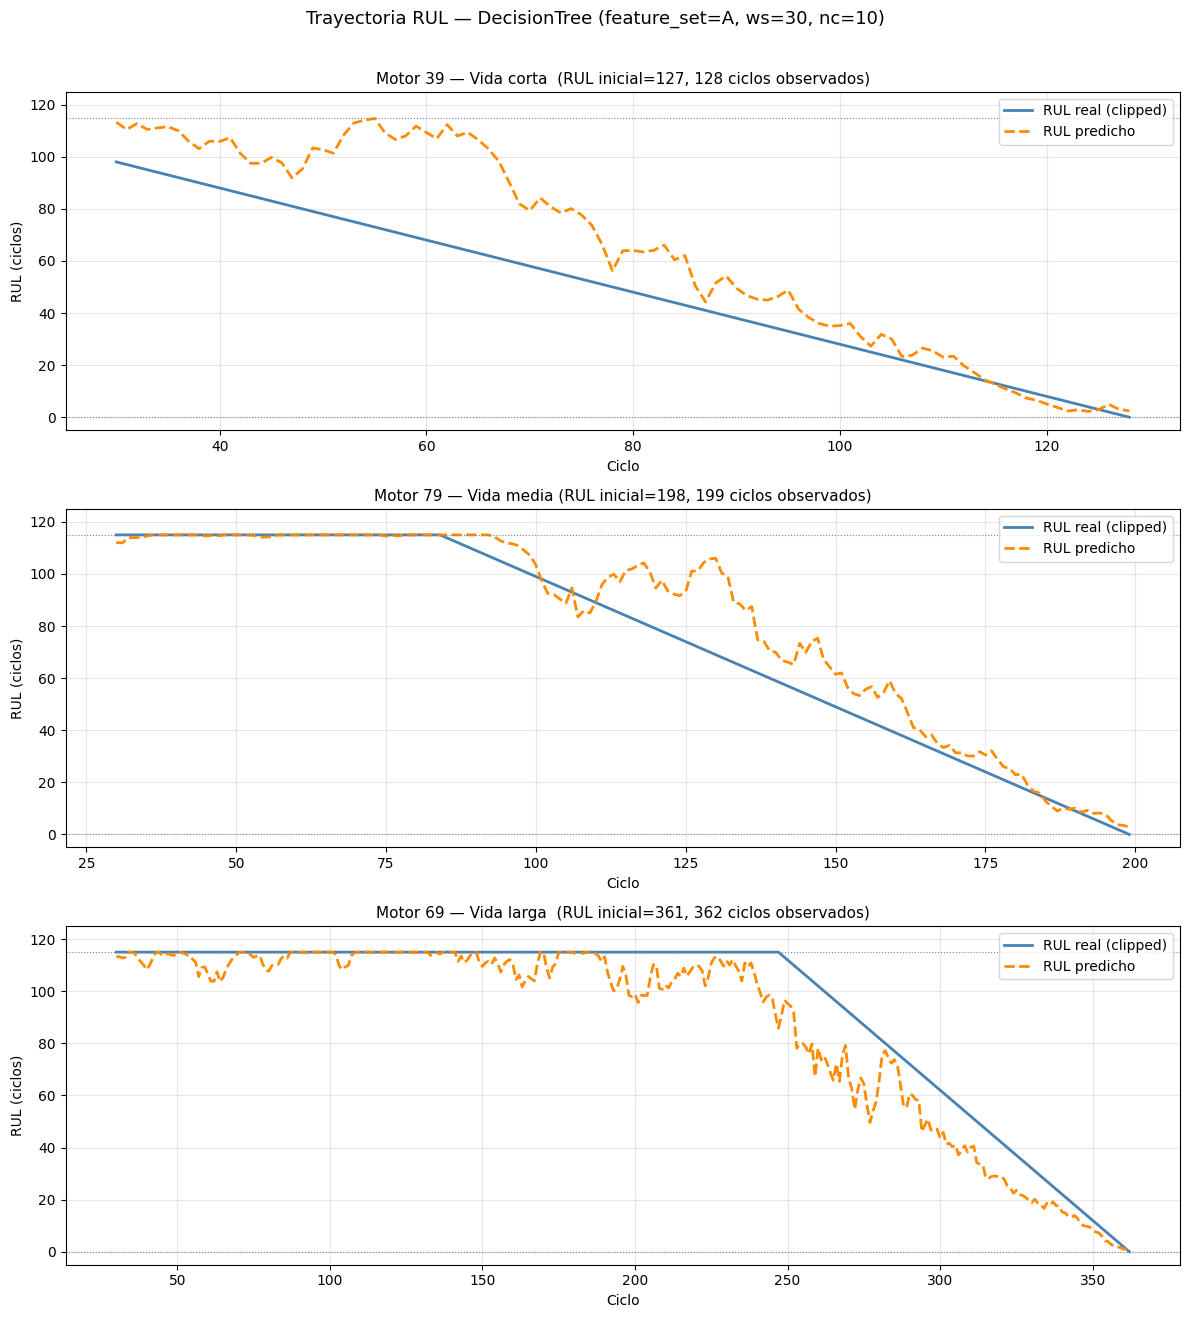

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

motores = [
    (39, 'Vida corta  (RUL inicial=127, 128 ciclos observados)'),
    (79, 'Vida media (RUL inicial=198, 199 ciclos observados)'),
    (69, 'Vida larga  (RUL inicial=361, 362 ciclos observados)'),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 13))

for ax, (motor_id, titulo) in zip(axes, motores):
    df_m = pd.read_csv(f'data/clean/data_motor_{motor_id}.csv')
    df_m.insert(0, 'unit_number', motor_id)
    X_m = df_m.drop(columns=['RUL'])

    _, _, t_stop_m, _, _ = predictor_dt.pipeline_.transform(X_m)
    rul_pred_m = predictor_dt.predict(X_m, return_mode='all')

    rul_real_m = np.minimum(
        df_m['RUL'].values[predictor_dt.window_size - 1:],
        predictor_dt.clipping_threshold,
    )

    ax.plot(t_stop_m, rul_real_m, label='RUL real (clipped)', color='steelblue',  linewidth=2)
    ax.plot(t_stop_m, rul_pred_m, label='RUL predicho',       color='darkorange', linewidth=2, linestyle='--')
    ax.axhline(y=0,                           color='gray', linewidth=0.8, linestyle=':')
    ax.axhline(y=predictor_dt.clipping_threshold, color='gray', linewidth=0.8, linestyle=':')

    ax.set_title(f'Motor {motor_id} — {titulo}', fontsize=11)
    ax.set_xlabel('Ciclo')
    ax.set_ylabel('RUL (ciclos)')
    ax.set_ylim(-5, predictor_dt.clipping_threshold + 10)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle('Trayectoria RUL — DecisionTree (feature_set=A, ws=30, nc=10)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()